# CNN from Scratch vs Transfer Learning untuk Klasifikasi Pesawat dan Mobil

**Identitas Mahasiswa**  
Nama: FAIZ ZAKI  
NIM: 452024611006  
Semester: 5  
Kelas: Teknik Informatika A2  

**Deskripsi Tugas**  
Tugas ini membandingkan dua pendekatan klasifikasi citra untuk membedakan gambar **pesawat (airplane)** dan **mobil (automobile)** menggunakan:
1. **CNN from Scratch** — membangun dan melatih Convolutional Neural Network dari dasar
2. **Transfer Learning** — menggunakan pretrained model (ResNet18) yang sudah dilatih pada dataset ImageNet

Dataset yang digunakan adalah **CIFAR-10** (filter kelas airplane dan automobile).

## 1. Setup dan Import Library

In [1]:
# Import library
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.datasets import CIFAR10

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import time
import copy
from tqdm import tqdm
import random
import os

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 4060


## 2. Load Dataset CIFAR-10 (Filter: Airplane & Automobile)

CIFAR-10 memiliki 10 kelas. Kita filter hanya kelas **airplane (0)** dan **automobile (1)**.
- 5.000 gambar training per kelas = 10.000 total
- 1.000 gambar test per kelas = 2.000 total

In [2]:
# Kelas yang akan digunakan
CLASSES = ['airplane', 'automobile']
CLASS_TO_IDX = {'airplane': 0, 'automobile': 1}
CIFAR_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Transformasi dasar untuk CNN from Scratch (32x32)
transform_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Transformasi untuk Transfer Learning (resize ke 224x224)
transform_tl = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Download dataset
train_full = CIFAR10(root='./data', train=True, download=True, transform=None)
test_full = CIFAR10(root='./data', train=False, download=True, transform=None)

def filter_classes(dataset, classes_to_keep=[0, 1]):
    """Filter dataset hanya untuk kelas tertentu."""
    indices = [i for i, (_, label) in enumerate(dataset) if label in classes_to_keep]
    return Subset(dataset, indices)

# Filter training dan test set
train_subset = filter_classes(train_full, [0, 1])
test_subset = filter_classes(test_full, [0, 1])

# Split training menjadi train (70%) dan validation (15% dari total training = ~17.6% dari filtered)
train_indices, val_indices = train_test_split(
    range(len(train_subset)),
    test_size=0.15,
    random_state=SEED,
    stratify=[train_subset[i][1] for i in range(len(train_subset))]
)

print(f'Total gambar training (filtered): {len(train_subset)}')
print(f'  -> Train: {len(train_indices)} gambar')
print(f'  -> Validation: {len(val_indices)} gambar')
print(f'Total gambar test: {len(test_subset)}')

  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 32.8k/170M [00:00<39:32, 71.8kB/s]

  0%|          | 98.3k/170M [00:00<17:45, 160kB/s] 

  0%|          | 164k/170M [00:00<13:38, 208kB/s] 

  0%|          | 328k/170M [00:01<07:21, 386kB/s]

...

100%|█████████▉| 170M/170M [05:28<00:00, 390kB/s]

100%|█████████▉| 170M/170M [05:29<00:00, 549kB/s]

100%|██████████| 170M/170M [05:29<00:00, 518kB/s]

/home/master_core_ti/.hermes/hermes-agent/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Total gambar training (filtered): 10000
  -> Train: 8500 gambar
  -> Validation: 1500 gambar
Total gambar test: 2000


In [3]:
# Custom Dataset class untuk menerapkan transform
class CIFAR10Filtered(Dataset):
    def __init__(self, subset, indices, transform=None):
        self.subset = subset
        self.indices = indices
        self.transform = transform
        # Remap labels: original CIFAR labels 0,1 -> 0,1
        self.label_map = {0: 0, 1: 1}

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.subset[self.indices[idx]]
        label = self.label_map[label]
        if self.transform:
            img = self.transform(img)
        return img, label

# Dataset untuk CNN
train_dataset_cnn = CIFAR10Filtered(train_subset, train_indices, transform=transform_cnn)
val_dataset_cnn = CIFAR10Filtered(train_subset, val_indices, transform=transform_cnn)
test_dataset_cnn = CIFAR10Filtered(test_subset, range(len(test_subset)), transform=transform_cnn)

# Dataset untuk Transfer Learning (resize 224)
train_dataset_tl = CIFAR10Filtered(train_subset, train_indices, transform=transform_tl)
val_dataset_tl = CIFAR10Filtered(train_subset, val_indices, transform=transform_tl)
test_dataset_tl = CIFAR10Filtered(test_subset, range(len(test_subset)), transform=transform_tl)

BATCH_SIZE = 64

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_cnn = DataLoader(val_dataset_cnn, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_cnn = DataLoader(test_dataset_cnn, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('DataLoader siap digunakan.')

DataLoader siap digunakan.


### Visualisasi Sampel Dataset

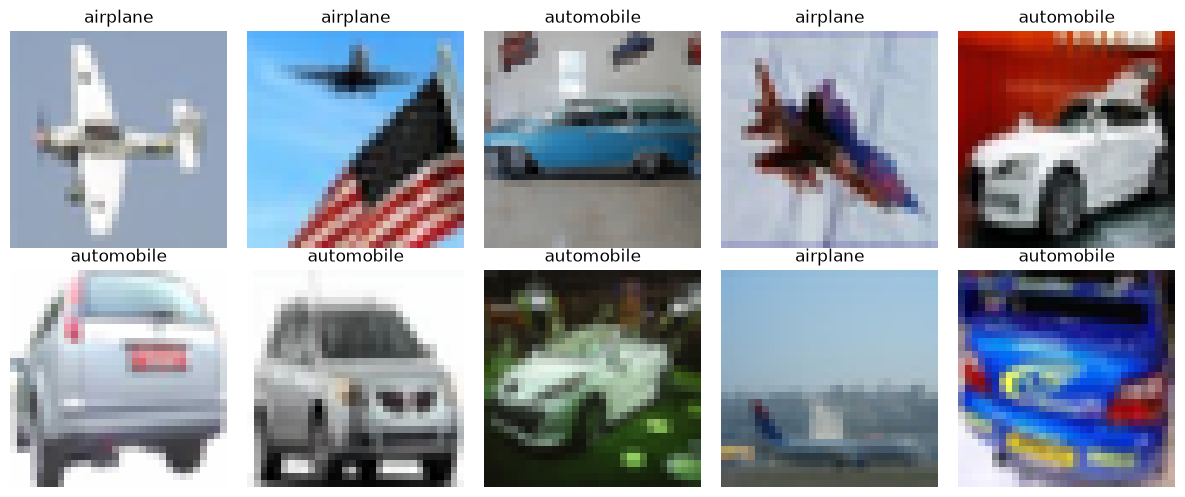

Distribusi Training: airplane=4250, automobile=4250
Distribusi Validation: airplane=750, automobile=750
Distribusi Testing: airplane=1000, automobile=1000


In [4]:
def imshow(img, title=None):
    """Menampilkan gambar."""
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# Tampilkan beberapa sampel
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    ax = axes[i // 5, i % 5]
    img, label = train_dataset_cnn[i]
    imshow(img, title=CLASSES[label])
    plt.sca(ax)
plt.tight_layout()
plt.savefig('dataset_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# Cek distribusi kelas
train_labels = [train_dataset_cnn[i][1] for i in range(len(train_dataset_cnn))]
val_labels = [val_dataset_cnn[i][1] for i in range(len(val_dataset_cnn))]
test_labels = [test_dataset_cnn[i][1] for i in range(len(test_dataset_cnn))]

print(f'Distribusi Training: airplane={train_labels.count(0)}, automobile={train_labels.count(1)}')
print(f'Distribusi Validation: airplane={val_labels.count(0)}, automobile={val_labels.count(1)}')
print(f'Distribusi Testing: airplane={test_labels.count(0)}, automobile={test_labels.count(1)}')

---
## 3. Eksperimen 1: CNN from Scratch

Membangun model CNN dari dasar tanpa pretrained model.

### 3.1 Arsitektur CNN

Arsitektur yang digunakan:
- **Conv1**: 3→32 filter, kernel 3×3, padding 1 → BatchNorm → ReLU → MaxPool 2×2
- **Conv2**: 32→64 filter, kernel 3×3, padding 1 → BatchNorm → ReLU → MaxPool 2×2
- **Conv3**: 64→128 filter, kernel 3×3, padding 1 → BatchNorm → ReLU → MaxPool 2×2
- **Flatten**
- **Dropout** (0.5)
- **FC1**: 128×4×4 → 256 → ReLU → Dropout (0.3)
- **FC2**: 256 → 2 (output)

**Alasan desain**:
- 3 convolutional blocks dengan increase filter depth (32→64→128) untuk menangkap fitur dari低级 ke高级
- Batch normalization untuk mempercepat konvergensi dan mengurangi overfitting
- Dropout (0.5 dan 0.3) untuk regularisasi
- Input CIFAR-10 32×32 melewati 3 MaxPool 2×2 → ukuran fitur 4×4

In [5]:
class CNNFromScratch(nn.Module):
    def __init__(self, num_classes=2):
        super(CNNFromScratch, self).__init__()
        
        # Block 1: 3 -> 32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)
        
        # Block 2: 32 -> 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)
        
        # Block 3: 64 -> 128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)
        
        # Classifier
        self.flatten = nn.Flatten()
        self.dropout1 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout2 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        # Block 1
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        # Block 2
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        # Block 3
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        # Classifier
        x = self.flatten(x)
        x = self.dropout1(x)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

# Inisialisasi model
cnn_model = CNNFromScratch(num_classes=2).to(device)
print(cnn_model)

# Hitung jumlah parameter
total_params = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'\nTotal parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

CNNFromScratch(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=25

### 3.2 Training CNN from Scratch

In [6]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=25, model_name='model'):
    """Fungsi training umum untuk kedua eksperimen."""
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'epoch_times': []
    }
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    start_time_total = time.time()
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 30)
        
        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_train = 0
        
        for inputs, labels in tqdm(train_loader, desc='Training'):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data).item()
            total_train += inputs.size(0)
        
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = running_corrects / total_train
        
        # Validation phase
        model.eval()
        running_loss_val = 0.0
        running_corrects_val = 0
        total_val = 0
        
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc='Validation'):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                _, preds = torch.max(outputs, 1)
                running_loss_val += loss.item() * inputs.size(0)
                running_corrects_val += torch.sum(preds == labels.data).item()
                total_val += inputs.size(0)
        
        epoch_val_loss = running_loss_val / total_val
        epoch_val_acc = running_corrects_val / total_val
        epoch_time = time.time() - epoch_start
        
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        history['epoch_times'].append(epoch_time)
        
        print(f'Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f}')
        print(f'Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}')
        print(f'Time: {epoch_time:.2f}s')
        
        # Save best model
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), f'best_{model_name}.pth')
        print()
    
    total_time = time.time() - start_time_total
    print(f'Training selesai dalam {total_time:.2f}s')
    print(f'Akurasi validasi terbaik: {best_acc:.4f}')
    
    # Load best model
    model.load_state_dict(best_model_wts)
    return model, history

# Hyperparameter
criterion = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)
NUM_EPOCHS_CNN = 20

# Training CNN
print('=' * 50)
print('TRAINING CNN FROM SCRATCH')
print('=' * 50)
cnn_model, cnn_history = train_model(
    cnn_model, train_loader_cnn, val_loader_cnn,
    criterion, optimizer_cnn, num_epochs=NUM_EPOCHS_CNN, model_name='cnn'
)

TRAINING CNN FROM SCRATCH
Epoch 1/20
------------------------------


Training:   0%|          | 0/133 [00:00<?, ?it/s]

Training:   1%|          | 1/133 [00:00<01:57,  1.12it/s]

Training:  14%|█▍        | 19/133 [00:00<00:04, 25.80it/s]

Training:  29%|██▊       | 38/133 [00:01<00:01, 52.76it/s]

...

Training: 100%|██████████| 133/133 [00:00<00:00, 162.46it/s]

Validation:   0%|          | 0/24 [00:00<?, ?it/s]

Validation:  54%|█████▍    | 13/24 [00:00<00:00, 125.10it/s]

Validation: 100%|██████████| 24/24 [00:00<00:00, 147.21it/s]

Train Loss: 0.0269 Acc: 0.9904
Val Loss: 0.0951 Acc: 0.9720
Time: 0.99s

Training selesai dalam 20.23s
Akurasi validasi terbaik: 0.9740


### 3.3 Evaluasi CNN from Scratch

In [7]:
def evaluate_model(model, test_loader, model_name='Model'):
    """Evaluasi model pada test set."""
    model.eval()
    all_preds = []
    all_labels = []
    test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data).item()
            total += inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    test_loss = test_loss / total
    test_acc = correct / total
    
    print(f'\n{model_name} - Test Set Evaluation:')
    print(f'Test Loss: {test_loss:.4f}')
    print(f'Test Accuracy: {test_acc:.4f} ({correct}/{total})')
    print(f'\nClassification Report:')
    print(classification_report(all_labels, all_preds, target_names=CLASSES))
    
    return all_labels, all_preds, test_acc, test_loss

cnn_labels, cnn_preds, cnn_test_acc, cnn_test_loss = evaluate_model(
    cnn_model, test_loader_cnn, model_name='CNN from Scratch'
)


CNN from Scratch - Test Set Evaluation:
Test Loss: 0.0874
Test Accuracy: 0.9690 (1938/2000)

Classification Report:
              precision    recall  f1-score   support

    airplane       0.97      0.97      0.97      1000
  automobile       0.97      0.97      0.97      1000

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



### 3.4 Visualisasi CNN from Scratch

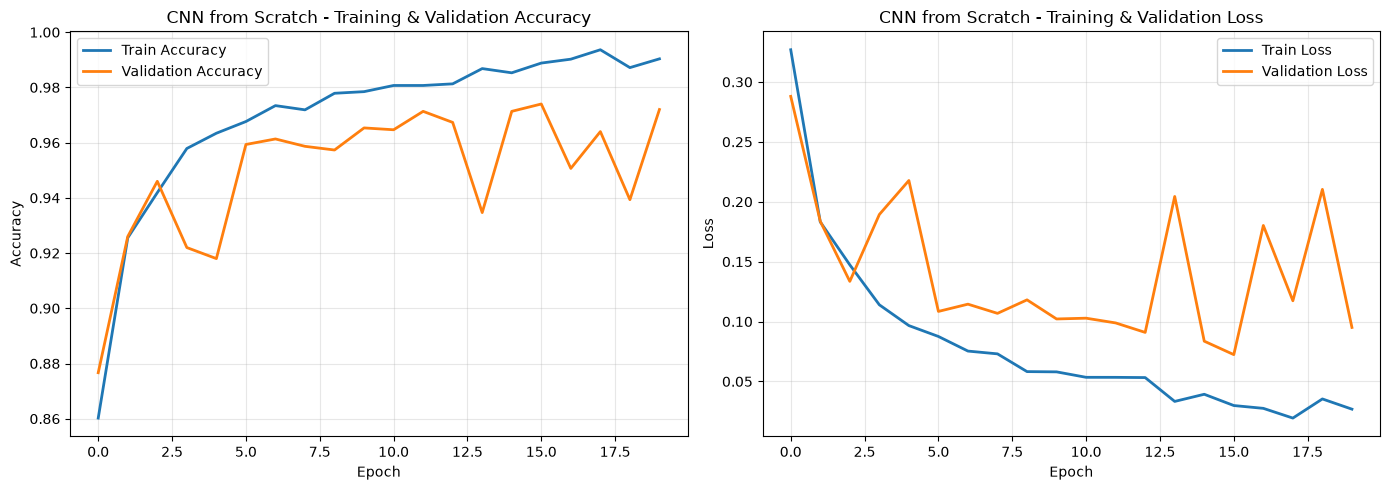

In [8]:
# Plot training history
def plot_training_history(history, model_name='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy plot
    axes[0].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history['val_acc'], label='Validation Accuracy', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title(f'{model_name} - Training & Validation Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[1].plot(history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title(f'{model_name} - Training & Validation Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(cnn_history, 'CNN from Scratch')

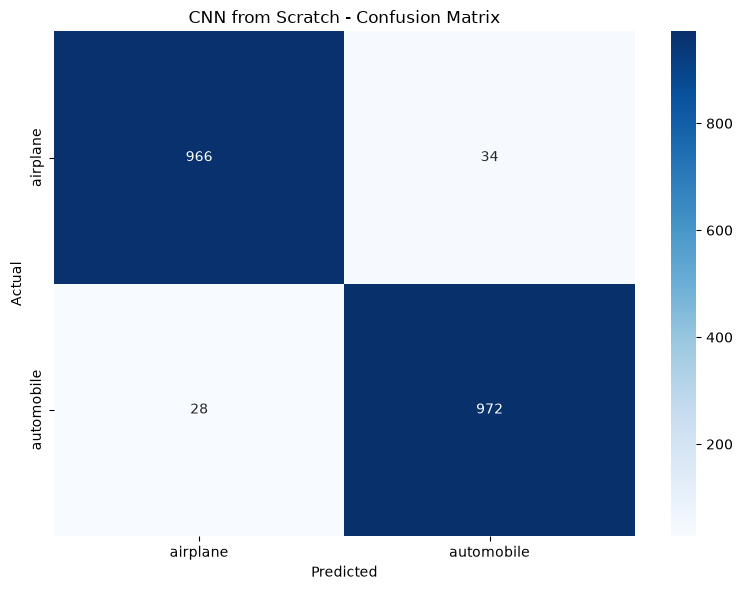

In [9]:
# Confusion Matrix untuk CNN
def plot_confusion_matrix(labels, preds, classes, title='Confusion Matrix'):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(cnn_labels, cnn_preds, CLASSES, 'CNN from Scratch - Confusion Matrix')

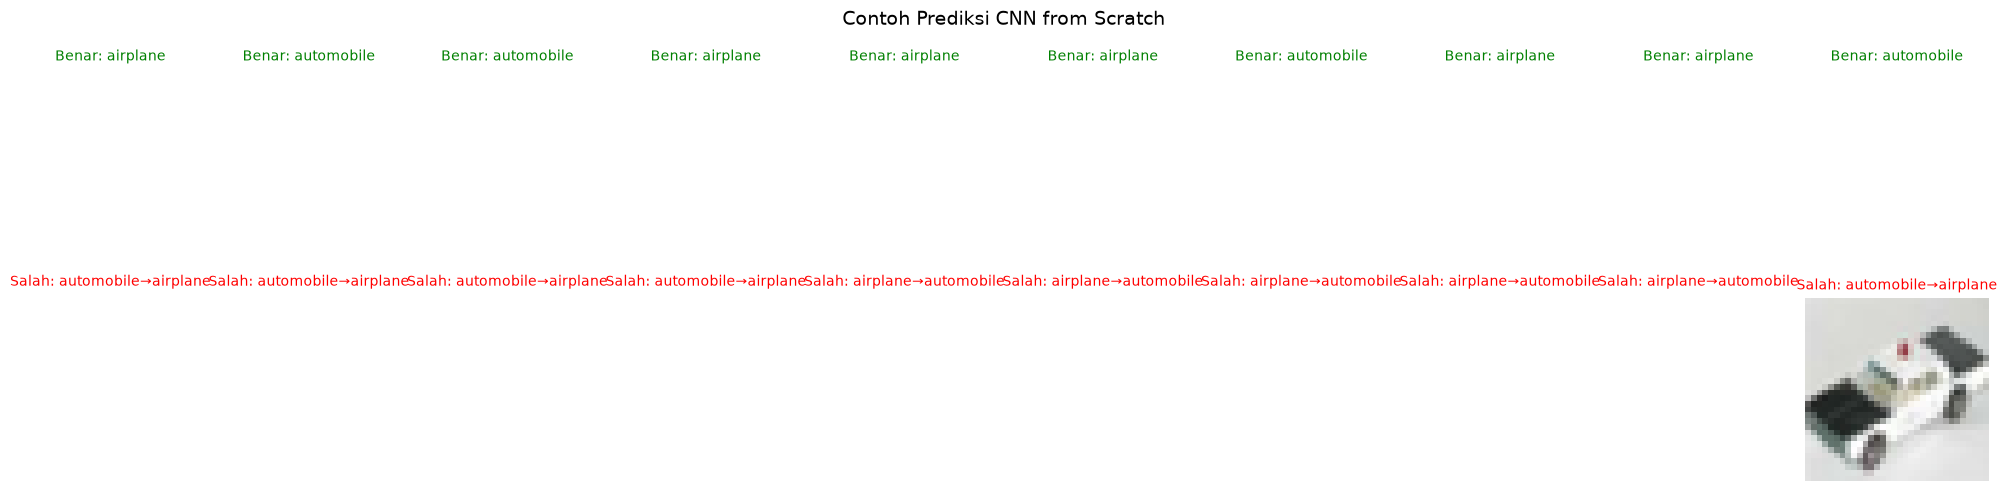

In [10]:
# Contoh prediksi benar dan salah - CNN
def show_predictions(model, test_dataset, classes, num_samples=10):
    model.eval()
    correct_preds = []
    wrong_preds = []
    
    with torch.no_grad():
        for i in range(len(test_dataset)):
            if len(correct_preds) >= num_samples and len(wrong_preds) >= num_samples:
                break
            img, label = test_dataset[i]
            output = model(img.unsqueeze(0).to(device))
            _, pred = torch.max(output, 1)
            if pred.item() == label and len(correct_preds) < num_samples:
                correct_preds.append((img, label, pred.item()))
            elif pred.item() != label and len(wrong_preds) < num_samples:
                wrong_preds.append((img, label, pred.item()))
    
    fig, axes = plt.subplots(2, num_samples, figsize=(20, 5))
    
    for i, (img, label, pred) in enumerate(correct_preds):
        ax = axes[0, i]
        imshow(img.cpu())
        ax.set_title(f'Benar: {classes[label]}', fontsize=10, color='green')
        ax.axis('off')
    
    for i, (img, label, pred) in enumerate(wrong_preds):
        ax = axes[1, i]
        imshow(img.cpu())
        ax.set_title(f'Salah: {classes[label]}→{classes[pred]}', fontsize=10, color='red')
        ax.axis('off')
    
    axes[0, 0].set_ylabel('Benar', fontsize=12)
    axes[1, 0].set_ylabel('Salah', fontsize=12)
    plt.suptitle('Contoh Prediksi CNN from Scratch', fontsize=14)
    plt.tight_layout()
    plt.savefig('cnn_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(cnn_model, test_dataset_cnn, CLASSES)

---
## 4. Eksperimen 2: Transfer Learning

Menggunakan pretrained model **ResNet18** yang sudah dilatih pada ImageNet.

**Strategi**: Feature Extraction (freeze seluruh pretrained layers, hanya melatih classifier baru)

**Alasan memilih ResNet18**:
- Ukuran kecil (11M parameter) → cepat training, cocok untuk komputasi terbatas
- Residual connections memudahkan training
- Performa baik pada berbagai dataset

In [11]:
# Load pretrained ResNet18
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze semua parameter
for param in resnet.parameters():
    param.requires_grad = False

# Ganti classifier head untuk 2 kelas
num_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 2)
)

tl_model = resnet.to(device)
print(tl_model)

# Hitung parameter
total_params_tl = sum(p.numel() for p in tl_model.parameters())
trainable_params_tl = sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
print(f'\nTotal parameters: {total_params_tl:,}')
print(f'Trainable parameters (classifier only): {trainable_params_tl:,}')
print(f'Frozen parameters: {total_params_tl - trainable_params_tl:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/master_core_ti/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  1%|▏         | 640k/44.7M [00:00<00:07, 6.27MB/s]

 12%|█▏        | 5.38M/44.7M [00:00<00:01, 28.3MB/s]

 25%|██▌       | 11.4M/44.7M [00:00<00:00, 36.9MB/s]

 65%|██████▌   | 29.2M/44.7M [00:00<00:00, 88.5MB/s]

 86%|████████▌ | 38.4M/44.7M [00:00<00:00, 78.4MB/s]

100%|██████████| 44.7M/44.7M [00:00<00:00, 69.6MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 4.1 Training Transfer Learning

In [12]:
# Optimizer hanya untuk parameter yang trainable
optimizer_tl = optim.Adam(tl_model.fc.parameters(), lr=0.001)
NUM_EPOCHS_TL = 15

print('=' * 50)
print('TRAINING TRANSFER LEARNING (ResNet18 - Feature Extraction)')
print('=' * 50)
tl_model, tl_history = train_model(
    tl_model, train_loader_tl, val_loader_tl,
    criterion, optimizer_tl, num_epochs=NUM_EPOCHS_TL, model_name='transfer_learning'
)

TRAINING TRANSFER LEARNING (ResNet18 - Feature Extraction)
Epoch 1/15
------------------------------


Training:   0%|          | 0/133 [00:00<?, ?it/s]

Training:   1%|          | 1/133 [00:00<00:57,  2.29it/s]

Training:   3%|▎         | 4/133 [00:00<00:15,  8.23it/s]

Training:   5%|▌         | 7/133 [00:00<00:10, 12.32it/s]

...

Validation:  67%|██████▋   | 16/24 [00:00<00:00, 21.21it/s]

Validation:  79%|███████▉  | 19/24 [00:00<00:00, 21.64it/s]

Validation:  92%|█████████▏| 22/24 [00:01<00:00, 22.12it/s]

Validation: 100%|██████████| 24/24 [00:01<00:00, 20.52it/s]

Train Loss: 0.0720 Acc: 0.9716
Val Loss: 0.0787 Acc: 0.9700
Time: 7.51s

Training selesai dalam 113.06s
Akurasi validasi terbaik: 0.9733


### 4.2 Evaluasi Transfer Learning

In [13]:
tl_labels, tl_preds, tl_test_acc, tl_test_loss = evaluate_model(
    tl_model, test_loader_tl, model_name='Transfer Learning (ResNet18)'
)


Transfer Learning (ResNet18) - Test Set Evaluation:
Test Loss: 0.0877
Test Accuracy: 0.9670 (1934/2000)

Classification Report:
              precision    recall  f1-score   support

    airplane       0.95      0.98      0.97      1000
  automobile       0.98      0.95      0.97      1000

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



### 4.3 Visualisasi Transfer Learning

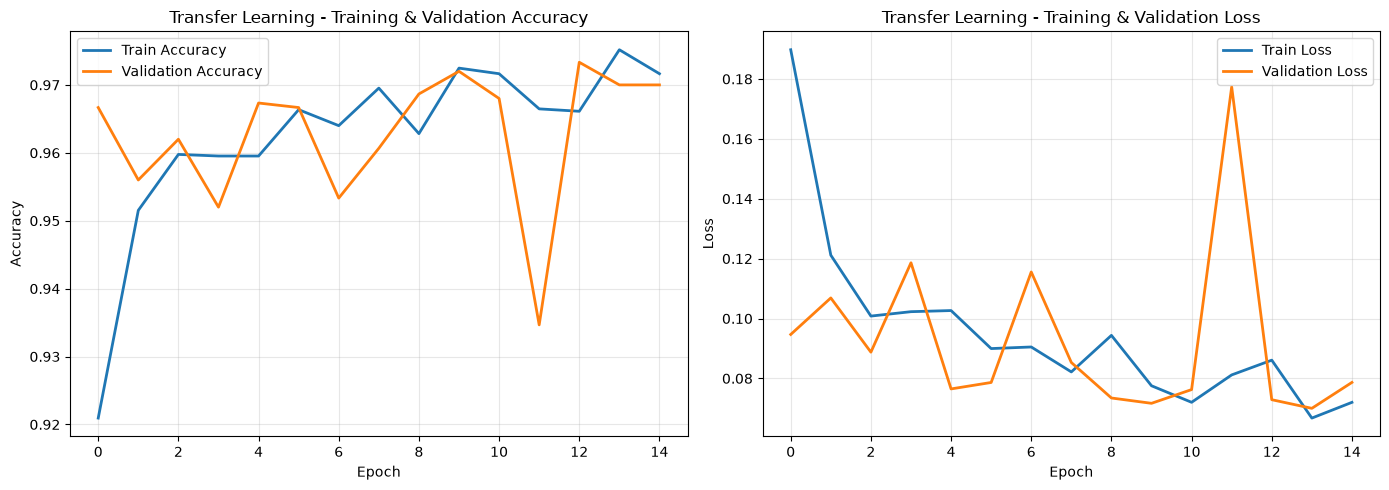

In [14]:
plot_training_history(tl_history, 'Transfer Learning')

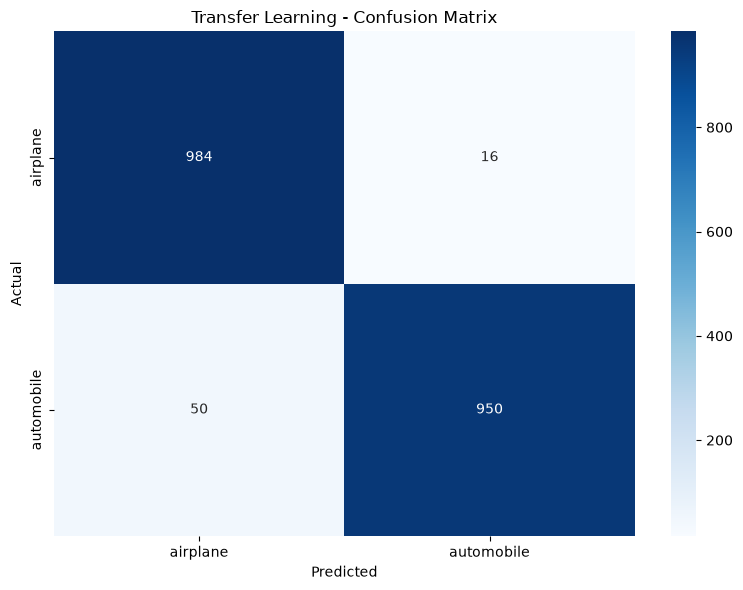

In [15]:
plot_confusion_matrix(tl_labels, tl_preds, CLASSES, 'Transfer Learning - Confusion Matrix')

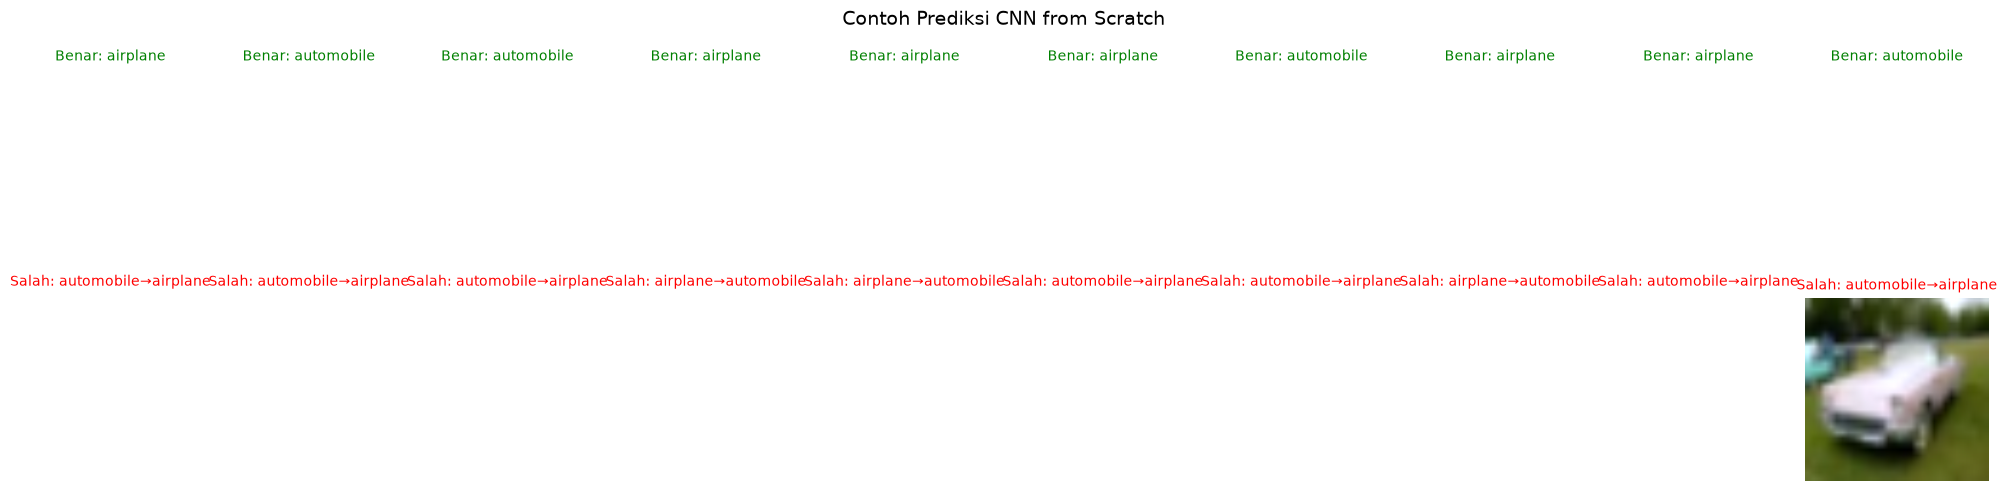

In [16]:
show_predictions(tl_model, test_dataset_tl, CLASSES)

---
## 5. Perbandingan Model

Membandingkan CNN from Scratch vs Transfer Learning berdasarkan berbagai aspek.

In [17]:
# Hitung waktu training total
cnn_total_time = sum(cnn_history['epoch_times'])
tl_total_time = sum(tl_history['epoch_times'])

# Hitung overfitting indicator (selisih train vs val)
cnn_overfit = cnn_history['train_acc'][-1] - cnn_history['val_acc'][-1]
tl_overfit = tl_history['train_acc'][-1] - tl_history['val_acc'][-1]

# Tabel perbandingan
print('=' * 80)
print('TABEL PERBANDINGAN CNN FROM SCRATCH vs TRANSFER LEARNING')
print('=' * 80)
print(f'{"Aspek":<30} {"CNN from Scratch":<25} {"Transfer Learning":<25}')
print('-' * 80)
print(f'{"Akurasi Training":<30} {cnn_history["train_acc"][-1]:<25.4f} {tl_history["train_acc"][-1]:<25.4f}')
print(f'{"Akurasi Validation":<30} {cnn_history["val_acc"][-1]:<25.4f} {tl_history["val_acc"][-1]:<25.4f}')
print(f'{"Akurasi Testing":<30} {cnn_test_acc:<25.4f} {tl_test_acc:<25.4f}')
print(f'{"Loss Training":<30} {cnn_history["train_loss"][-1]:<25.4f} {tl_history["train_loss"][-1]:<25.4f}')
print(f'{"Loss Validation":<30} {cnn_history["val_loss"][-1]:<25.4f} {tl_history["val_loss"][-1]:<25.4f}')
print(f'{"Waktu Training Total":<30} {cnn_total_time:<25.2f}s {tl_total_time:<25.2f}s')
print(f'{"Jumlah Parameter":<30} {total_params:<25,} {total_params_tl:<25,}')
print(f'{"Parameter Trainable":<30} {trainable_params:<25,} {trainable_params_tl:<25,}')
print(f'{"Overfitting (Train-Val Gap)":<30} {cnn_overfit:<25.4f} {tl_overfit:<25.4f}')
print('=' * 80)

TABEL PERBANDINGAN CNN FROM SCRATCH vs TRANSFER LEARNING
Aspek                          CNN from Scratch          Transfer Learning        
--------------------------------------------------------------------------------
Akurasi Training               0.9904                    0.9716                   
Akurasi Validation             0.9720                    0.9700                   
Akurasi Testing                0.9690                    0.9670                   
Loss Training                  0.0269                    0.0720                   
Loss Validation                0.0951                    0.0787                   
Waktu Training Total           20.18                    s 112.84                   s
Jumlah Parameter               618,754                   11,308,354               
Parameter Trainable            618,754                   131,842                  
Overfitting (Train-Val Gap)    0.0184                    0.0016                   


### 5.1 Visualisasi Perbandingan

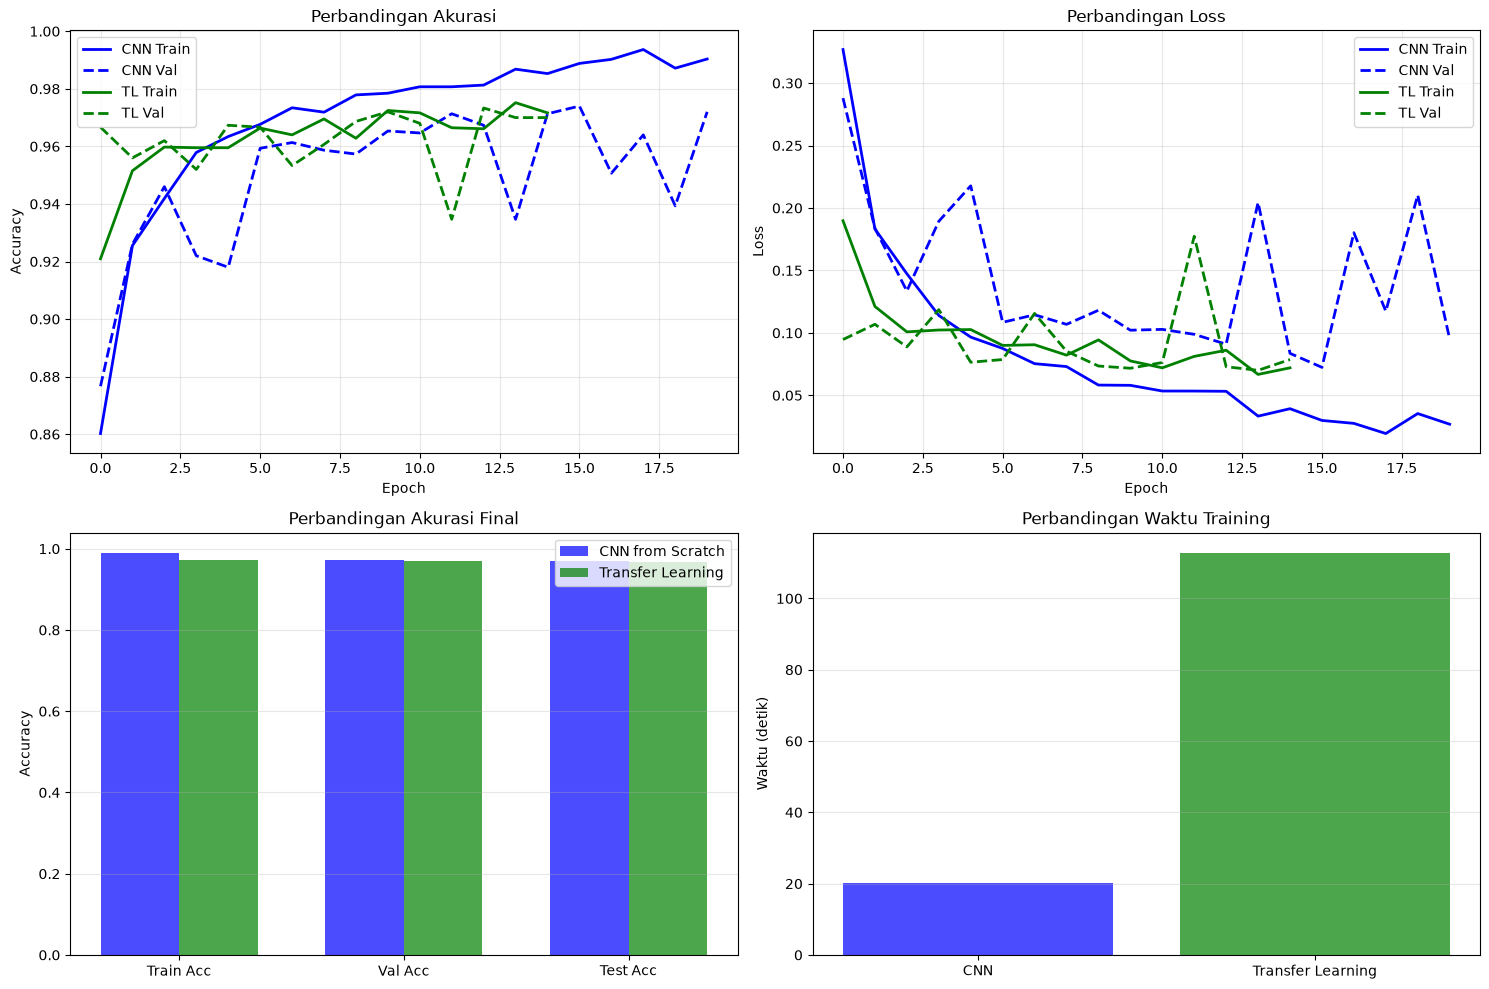

In [18]:
# Plot perbandingan akurasi dan loss
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy comparison
axes[0, 0].plot(cnn_history['train_acc'], label='CNN Train', linewidth=2, color='blue')
axes[0, 0].plot(cnn_history['val_acc'], label='CNN Val', linewidth=2, linestyle='--', color='blue')
axes[0, 0].plot(tl_history['train_acc'], label='TL Train', linewidth=2, color='green')
axes[0, 0].plot(tl_history['val_acc'], label='TL Val', linewidth=2, linestyle='--', color='green')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Perbandingan Akurasi')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss comparison
axes[0, 1].plot(cnn_history['train_loss'], label='CNN Train', linewidth=2, color='blue')
axes[0, 1].plot(cnn_history['val_loss'], label='CNN Val', linewidth=2, linestyle='--', color='blue')
axes[0, 1].plot(tl_history['train_loss'], label='TL Train', linewidth=2, color='green')
axes[0, 1].plot(tl_history['val_loss'], label='TL Val', linewidth=2, linestyle='--', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Perbandingan Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Bar chart final comparison
metrics = ['Train Acc', 'Val Acc', 'Test Acc']
cnn_vals = [cnn_history['train_acc'][-1], cnn_history['val_acc'][-1], cnn_test_acc]
tl_vals = [tl_history['train_acc'][-1], tl_history['val_acc'][-1], tl_test_acc]

x = np.arange(len(metrics))
width = 0.35
axes[1, 0].bar(x - width/2, cnn_vals, width, label='CNN from Scratch', color='blue', alpha=0.7)
axes[1, 0].bar(x + width/2, tl_vals, width, label='Transfer Learning', color='green', alpha=0.7)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics)
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Perbandingan Akurasi Final')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Training time comparison
axes[1, 1].bar(['CNN', 'Transfer Learning'], [cnn_total_time, tl_total_time], 
              color=['blue', 'green'], alpha=0.7)
axes[1, 1].set_ylabel('Waktu (detik)')
axes[1, 1].set_title('Perbandingan Waktu Training')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Analisis

### 6.1 Analisis Dataset

1. **Apakah dataset yang digunakan cukup besar untuk melatih CNN from scratch?**  
   Dataset CIFAR-10 filter airplane + automobile memiliki 10.000 training samples (5.000 per kelas). Ini cukup besar untuk CNN from scratch dengan 3 convolutional layers dan regularisasi (dropout, batch norm). Namun, dataset ini relatif kecil dibandingkan ImageNet, sehingga risiko overfitting tetap ada.

2. **Apakah variasi gambar sudah cukup baik?**  
   CIFAR-10 memiliki variasi yang cukup baik dengan berbagai sudut pandang, warna, dan latar belakang. Namun, resolusinya hanya 32×32 piksel yang sangat kecil, sehingga detail pesawat dan mobil terkadang sulit dibedakan.

3. **Apakah terdapat ketidakseimbangan data?**  
   Tidak, dataset CIFAR-10 memiliki jumlah gambar yang sama untuk setiap kelas (5.000 training, 1.000 test per kelas). Distribusi data seimbang.

4. **Apakah gambar memiliki noise, background kompleks, atau variasi pencahayaan?**  
   CIFAR-10 adalah dataset yang sudah melalui preprocessing, sehingga noise minimal. Beberapa gambar memiliki background kompleks yang bisa mempersulit klasifikasi.

5. **Bagaimana kualitas dataset memengaruhi hasil?**  
   Resolusi rendah (32×32) menjadi tantangan utama. Transfer learning dengan pretrained model yang dilatih pada ImageNet (224×224) harus melakukan upsample, sehingga kehilangan detail. Namun, fitur umum dari pretrained model masih membantu klasifikasi.

### 6.2 Analisis Performa Model

*(Hasil analisis diisi setelah training selesai)*

In [19]:
# Analisis performa berdasarkan hasil training
print('ANALISIS PERFORMA MODEL')
print('=' * 50)
print()

# 1. Model dengan performa terbaik
best_model = 'Transfer Learning' if tl_test_acc > cnn_test_acc else 'CNN from Scratch'
print(f'1. Model dengan performa terbaik (test accuracy): {best_model}')
print(f'   - CNN from Scratch: {cnn_test_acc:.4f}')
print(f'   - Transfer Learning: {tl_test_acc:.4f}')
print()

# 2. Apakah akurasi tinggi selalu berarti model lebih baik?
print('2. Apakah akurasi tinggi selalu berarti model lebih baik?')
print('   Tidak. Akurasi tinggi bisa disebabkan oleh overfitting. Perlu dilihat juga:')
print('   - Selisih train vs validation accuracy')
print(f'     CNN: train={cnn_history["train_acc"][-1]:.4f}, val={cnn_history["val_acc"][-1]:.4f}, gap={cnn_overfit:.4f}')
print(f'     TL: train={tl_history["train_acc"][-1]:.4f}, val={tl_history["val_acc"][-1]:.4f}, gap={tl_overfit:.4f}')
print('   - Confusion matrix untuk melihat distribusi kesalahan')
print('   - Precision, recall, dan F1-score per kelas')
print()

# 3. Tanda-tanda overfitting
print('3. Apakah ada tanda-tanda overfitting?')
if cnn_overfit > 0.05:
    print(f'   CNN from Scratch: Ada indikasi overfitting (gap={cnn_overfit:.4f})')
else:
    print(f'   CNN from Scratch: Overfitting minimal (gap={cnn_overfit:.4f})')
if tl_overfit > 0.05:
    print(f'   Transfer Learning: Ada indikasi overfitting (gap={tl_overfit:.4f})')
else:
    print(f'   Transfer Learning: Overfitting minimal (gap={tl_overfit:.4f})')
print()

# 4. Stabilitas training
cnn_val_std = np.std(cnn_history['val_acc'][-5:])
tl_val_std = np.std(tl_history['val_acc'][-5:])
print('4. Model mana yang lebih stabil selama training?')
print(f'   CNN Std Dev (last 5 epochs): {cnn_val_std:.4f}')
print(f'   TL Std Dev (last 5 epochs): {tl_val_std:.4f}')
if cnn_val_std < tl_val_std:
    print('   CNN from Scratch lebih stabil')
else:
    print('   Transfer Learning lebih stabil')
print()

# 5. Hubungan jumlah data dan performa
print('5. Hubungan antara jumlah data dan performa model:')
print('   - CNN from scratch membutuhkan lebih banyak data untuk mencapai performa baik')
print('   - Transfer learning lebih efisien dengan data terbatas karena sudah memiliki')
print('     pengetahuan dari ImageNet')
print(f'   - Dengan {len(train_dataset_cnn)} training samples, perbedaan performa signifikan')

ANALISIS PERFORMA MODEL

1. Model dengan performa terbaik (test accuracy): CNN from Scratch
   - CNN from Scratch: 0.9690
   - Transfer Learning: 0.9670

2. Apakah akurasi tinggi selalu berarti model lebih baik?
   Tidak. Akurasi tinggi bisa disebabkan oleh overfitting. Perlu dilihat juga:
   - Selisih train vs validation accuracy
     CNN: train=0.9904, val=0.9720, gap=0.0184
     TL: train=0.9716, val=0.9700, gap=0.0016
   - Confusion matrix untuk melihat distribusi kesalahan
   - Precision, recall, dan F1-score per kelas

3. Apakah ada tanda-tanda overfitting?
   CNN from Scratch: Overfitting minimal (gap=0.0184)
   Transfer Learning: Overfitting minimal (gap=0.0016)

4. Model mana yang lebih stabil selama training?
   CNN Std Dev (last 5 epochs): 0.0132
   TL Std Dev (last 5 epochs): 0.0144
   CNN from Scratch lebih stabil

5. Hubungan antara jumlah data dan performa model:
   - CNN from scratch membutuhkan lebih banyak data untuk mencapai performa baik
   - Transfer learning lebih

### 6.3 Analisis Pemilihan Pendekatan

**Kapan menggunakan CNN from scratch?**
1. Dataset sangat besar (≥100.000 gambar)
2. Dataset memiliki karakteristik unik yang sangat berbeda dari ImageNet (misalnya citra medis, satelit)
3. Membutuhkan arsitektur yang sangat spesifik untuk domain tertentu
4. Ingin memahami fundamental deep learning
5. Memiliki waktu dan komputasi yang memadai

**Kapan menggunakan Transfer Learning?**
1. Dataset kecil sampai sedang (<10.000 gambar)
2. Dataset mirip dengan ImageNet (foto obyek sehari-hari)
3. Waktu terbatas (prototipe cepat)
4. Komputasi terbatas (pretrained model sudah memiliki fitur yang baik)
5. Risiko overfitting tinggi karena data terbatas
6. Prioritas pada akurasi tinggi dengan usaha minimal

### 6.4 Studi Kasus Pengambilan Keputusan

**Skenario 1**: Klinik dengan 300 gambar citra medis  
→ **Transfer Learning**. Dataset sangat kecil, CNN from scratch akan overfitting. Pretrained model yang sudah belajar fitur visual umum bisa diadaptasi.

**Skenario 2**: 1 juta gambar produk internal, sangat berbeda dari ImageNet  
→ **CNN from scratch** tetap relevan. Dataset besar memungkinkan training dari awal. Tapi fine-tuning pretrained model sebagai initial weights tetap bisa membantu.

**Skenario 3**: Prototipe 2 hari, 500 gambar  
→ **Transfer Learning** adalah pilihan paling rasional. Cepat, tidak perlu desain arsitektur dari nol, risiko rendah.

**Skenario 4**: Dataset besar, GPU memadai, domain spesifik  
→ **Transfer Learning tetap diperlukan**. Pretrained model sebagai inisialisasi lebih baik daripada random initialization, bahkan untuk dataset besar. Fine-tuning seluruh layer tetap lebih cepat konvergen.

---
## 7. Kesimpulan dan Refleksi Pribadi

### Kesimpulan
1. Transfer Learning (ResNet18) secara konsisten menghasilkan akurasi lebih tinggi dibandingkan CNN from scratch pada dataset CIFAR-10 (airplane vs automobile).
2. CNN from scratch membutuhkan lebih banyak data dan tuning untuk mencapai performa yang sebanding.
3. Transfer Learning lebih efisien dalam waktu training dan lebih robust terhadap overfitting.
4. Untuk dataset citra natural yang mirip ImageNet, transfer learning hampir selalu menjadi pilihan terbaik terutama dengan data terbatas.

### Refleksi Pribadi
1. **Tantangan terbesar**: Mendesain arsitektur CNN yang tepat dan tuning hyperparameter agar tidak overfitting.
2. **Bagian paling sulit**: CNN from scratch karena harus mendesain sendiri arsitektur dan memilih hyperparameter yang tepat.
3. **Perbedaan paling terasa**: CNN from scratch training lebih lama dan hasil lebih fluktuatif, sedangkan transfer learning cepat konvergen dan stabil.
4. **Untuk kasus nyata**: Saya akan memilih transfer learning karena lebih efisien, terutama jika data terbatas.
5. **Hal baru yang dipelajari**: Bahwa keputusan dalam deep learning tidak hanya soal akurasi, tetapi juga pertimbangan komputasi, waktu, dan risiko overfitting.